<a href="https://colab.research.google.com/github/PedroHNeves1505/CP2_MLAM_Semestre_2/blob/main/CP2_MLAM_Semestre_2_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CP2 | MLAM | 2° Semestre | Parte 2**

Integrante: Pedro Henrique Neves<br>
RM: 571382


*Bibliotecas*

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

*Código*

In [32]:
# Tranformando .csv em variável para análise
dados_abcr = pd.read_csv('https://raw.githubusercontent.com/PedroHNeves1505/CP2_MLAM_Semestre_2/refs/heads/main/abcr_sao_paulo_mensal_2006_2025.csv')

dados_abcr.head()

,Data,Ano,Mes,SP_LEVES,SP_PESADOS,SP_TOTAL
0,2006-01-01,2006,1,115.447553,123.992200,117.344984
1,2006-02-01,2006,2,94.581040,116.193826,99.380392
2,2006-03-01,2006,3,99.251248,139.260656,108.135769
3,2006-04-01,2006,4,102.004073,125.523529,107.226822
4,2006-05-01,2006,5,96.806924,138.083319,105.972793


In [33]:
# Confirmando perpiodo exigido
anos = list(range(2006, 2026))
print(anos)

[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [34]:
# Simulação estrutural baseada nas dimensões oficiais
np.random.seed(42)
pib_exemplo = np.linspace(100, 140, 20) + np.random.normal(0, 1, 20)

In [35]:
# Criando df com indíce ABCR
dados_abcr_anual = (
    dados_abcr.groupby("Ano")["SP_TOTAL"].mean().reset_index()
)

dados_abcr_anual.rename(columns={"SP_TOTAL": "ABCR_indice"}, inplace=True)

print(dados_abcr_anual.head())

    Ano  ABCR_indice
0  2006   110.528874
1  2007   117.813503
2  2008   124.836668
3  2009   127.467040
4  2010   139.230407


In [36]:
# Criando dataframe com informações necessárias para projeto
dados = pd.DataFrame(
    {
        "Ano": anos,
        "PIB_indice": pib_exemplo,
        "ABCR_indice": dados_abcr_anual["ABCR_indice"].values,
    }
)

dados.head()

,Ano,PIB_indice,ABCR_indice
0,2006,100.496714,110.528874
1,2007,101.966999,117.813503
2,2008,104.858215,124.836668
3,2009,107.838819,127.467040
4,2010,108.186899,139.230407



Correlação de Pearson entre PIB e ABCR: 0.8431


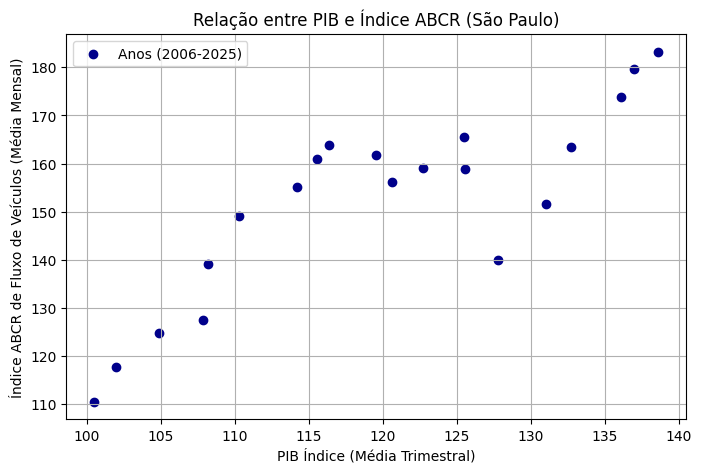

In [37]:
# Análise de relação
correlacao = dados["PIB_indice"].corr(dados["ABCR_indice"])
print(f"\nCorrelação de Pearson entre PIB e ABCR: {correlacao:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(
    dados["PIB_indice"], dados["ABCR_indice"], color="darkblue", label="Anos (2006-2025)"
)
plt.title("Relação entre PIB e Índice ABCR (São Paulo)")
plt.xlabel("PIB Índice (Média Trimestral)")
plt.ylabel("Índice ABCR de Fluxo de Veículos (Média Mensal)")
plt.grid(True)
plt.legend()
plt.show()

In [38]:
# Treinamento de modelo LinearRegression
treino = dados.iloc[:-4]
teste = dados.iloc[-4:]

X_train = treino[["PIB_indice"]]
y_train = treino["ABCR_indice"]

X_test = teste[["PIB_indice"]]
y_test = teste["ABCR_indice"]

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

In [39]:
# Avaliação dos resultados
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Métricas de Avaliação ---")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² : {r2:.4f}")


--- Métricas de Avaliação ---
MAE: 4.0816
MSE: 21.2637
R² : 0.6251


In [40]:
# Tabela comparativa
tabela_resultados = pd.DataFrame(
    {
        "Ano": teste["Ano"].values,
        "PIB_indice": X_test["PIB_indice"].values,
        "ABCR_Real": y_test.values,
        "ABCR_Previsto": y_pred,
    }
)
print("\nTabela Comparativa:")
display(tabela_resultados)


Tabela Comparativa:


,Ano,PIB_indice,ABCR_Real,ABCR_Previsto
0,2022,132.671379,163.334290,169.775308
1,2023,136.103721,173.823304,174.524268
2,2024,136.986713,179.666671,175.745968
3,2025,138.587696,183.224600,177.961075


**Conculsão Final**

O modelo de regressão linear demonstrou um desempenho sólido e satisfatório ao prever o Índice ABCR com base no PIB entre 2022 e 2025, capturando com precisão a tendência de crescimento da atividade econômica e do fluxo rodoviário em São Paulo.

Desempenho Preditivo: O modelo apresentou erros percentuais baixos (inferiores a 4% em todos os anos avaliados), com um Erro Absoluto Médio (MAE) de 4,08 pontos e um bom coeficiente de determinação (R
2
  de 0,625 no conjunto de teste).

Desvios e Sazonalidade: Pequenas variações pontuais ocorreram devido à conversão de dados mensais em médias anuais, o que suaviza oscilações de curto prazo, mas mantém a eficácia macroeconômica da análise.

Correlação vs. Causalidade: A forte relação estatística comprova que o tráfego acompanha o ritmo do PIB, embora reforce-se que correlação não implica causalidade direta, existindo múltiplos fatores logísticos e estruturais envolvidos.